# Feature Engineering

Notebook 01 found that no raw column has |r| > 0.05 with Yield. So a model that only sees the raw 46 columns will never reach a useful R-squared. In this notebook we build two kinds of derived features:

1. Classical agronomic ratios (NPK ratio, soil health index, weather stress, vegetation index).
2. Latent proxies built as weighted z-scores of related raw columns (climate, soil, management, water, terrain) plus three tanh-bounded interactions of those proxies.

We then check whether the new features actually correlate with Yield, do the train/test split, and save a fitted preprocessor.

## Imports

In [1]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
ROOT = Path('.').resolve().parent if Path('.').resolve().name == 'notebooks' else Path('.').resolve()
RAW_PATH = ROOT / 'data' / 'raw' / 'Agri_yield_prediction.csv'
PROC_DIR = ROOT / 'data' / 'processed'
MODEL_DIR = ROOT / 'models'
FIG_DIR = ROOT / 'figures'
for d in (PROC_DIR, MODEL_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

## Load raw data

In [2]:
df_raw = pd.read_csv(RAW_PATH)
print('Raw shape:', df_raw.shape)
df_raw.head(3)

Raw shape: (36000, 46)


,Temperature,Humidity,Rainfall,Soil_Type,pH,EC,OC,N,P,K,...,Planting_Date,Harvest_Date,Growth_Stage,Irrigation_Frequency,Fertilizer_Type,Pesticide_Usage,Yield,Region,Season,Year
0,20.217609,71.563782,48.837768,Clayey,6.467371,1.317873,0.656934,138.565862,65.148562,197.716636,...,2023-10-19,2024-01-29,Vegetative,4,Organic,Low,5.340428,West,Rabi,2023
1,34.144330,62.473178,253.900950,Sandy,7.087405,1.564200,0.748017,82.633876,37.236441,99.902932,...,2009-08-23,2009-11-13,Reproductive,4,Mixed,High,6.633464,North,Kharif,2009
2,20.842568,60.215798,128.300095,Loamy,6.685763,1.162799,1.185390,140.045407,72.826335,151.476596,...,2022-12-23,2023-04-11,Vegetative,5,Mixed,High,7.088017,South,Rabi,2022


## Build engineered features

In [3]:
def add_engineered_features(df):
    out = df.copy()
    out['Planting_Date'] = pd.to_datetime(out['Planting_Date'])
    out['Harvest_Date'] = pd.to_datetime(out['Harvest_Date'])
    out['Crop_Duration'] = (out['Harvest_Date'] - out['Planting_Date']).dt.days
    out['Planting_Month'] = out['Planting_Date'].dt.month
    out['Harvest_Month'] = out['Harvest_Date'].dt.month
    out = out.drop(columns=['Planting_Date', 'Harvest_Date'])

    out['NPK_ratio'] = out['N'] / (out['P'] + out['K'] + 1.0)
    out['Soil_Health_Index'] = out['OC'] + out['CEC'] / 10 + out['Ca'] / 1000 + out['Mg'] / 200
    out['Micronutrient_Score'] = out[['Cu', 'Zn', 'Fe', 'Mn', 'B', 'Mo']].sum(axis=1)
    out['Weather_Stress'] = np.abs(out['Temperature'] - 25.0) + np.abs(out['Rainfall'] - 150.0) / 100.0
    out['Vegetation_Index'] = out['NDVI'] * out['LAI'] * out['Chlorophyll'] / 50.0
    out['Soil_Water_Interaction'] = out['Water_Holding_Capacity'] * out['Bulk_Density']
    out['Terrain_Risk_Proxy'] = out['Sand'] / 100 + out['Slope'] / 30 + out['Elevation'] / 2000
    out['Management_Proxy'] = out['NDVI'] + out['LAI'] / 3 + out['Chlorophyll'] / 40

    def z(col):
        return (out[col] - out[col].mean()) / out[col].std()

    out['Climate_Proxy'] = (
        0.35 * z('Temperature') + 0.30 * z('Rainfall') + 0.15 * z('Humidity')
        + 0.10 * z('Solar_Radiation') - 0.10 * z('Wind_Speed')
    )
    out['Soil_Proxy'] = (
        0.20 * z('OC') + 0.18 * z('CEC') + 0.16 * z('Ca') + 0.14 * z('Mg')
        + 0.20 * z('Cu') + 0.18 * z('Mo') + 0.10 * z('Zn') + 0.08 * z('Fe') + 0.10 * z('N')
    )
    out['Management_Quality_Proxy'] = (
        0.35 * z('NDVI') + 0.30 * z('LAI') + 0.25 * z('Chlorophyll')
        + 0.10 * out['Fertilizer_Type'].map({'Chemical': -1.0, 'Organic': 1.0, 'Mixed': 0.5}).astype(float)
        + 0.10 * out['Pesticide_Usage'].map({'Low': 1.0, 'Medium': 0.0, 'High': -1.0}).astype(float)
    )
    out['Water_Proxy'] = (
        0.40 * z('Rainfall') + 0.25 * z('Water_Holding_Capacity')
        - 0.20 * z('Bulk_Density') + 0.15 * z('Irrigation_Frequency')
    )
    out['Terrain_Proxy'] = (
        0.35 * z('Sand') - 0.20 * z('Silt') - 0.25 * z('Clay')
        + 0.25 * z('Slope') + 0.15 * z('Elevation')
    )
    out['SoilHealth_Management_interaction'] = np.tanh(out['Soil_Proxy'] * out['Management_Quality_Proxy'])
    out['Climate_Water_interaction'] = np.tanh(out['Climate_Proxy'] * out['Water_Proxy'])
    out['Management_Water_interaction'] = np.tanh(out['Management_Quality_Proxy'] * out['Water_Proxy'])
    return out

df = add_engineered_features(df_raw)

### What did we add?

In [4]:
before = df_raw.shape[1]
after = df.shape[1]
added = sorted(set(df.columns) - set(df_raw.columns))
removed = sorted(set(df_raw.columns) - set(df.columns))
print(f'Original columns: {before}')
print(f'After engineering: {after}')
print(f'Net new columns: {len(added) - len(removed)}')
print()
print('Added:')
for c in added:
    print(' ', c)
print()
print('Removed (date columns, replaced by Crop_Duration / Planting_Month / Harvest_Month):')
for c in removed:
    print(' ', c)

Original columns: 46
After engineering: 63
Net new columns: 17

Added:
  Climate_Proxy
  Climate_Water_interaction
  Crop_Duration
  Harvest_Month
  Management_Proxy
  Management_Quality_Proxy
  Management_Water_interaction
  Micronutrient_Score
  NPK_ratio
  Planting_Month
  SoilHealth_Management_interaction
  Soil_Health_Index
  Soil_Proxy
  Soil_Water_Interaction
  Terrain_Proxy
  Terrain_Risk_Proxy
  Vegetation_Index
  Water_Proxy
  Weather_Stress

Removed (date columns, replaced by Crop_Duration / Planting_Month / Harvest_Month):
  Harvest_Date
  Planting_Date


## Did the engineered features actually correlate with Yield?

This is the key justification for feature engineering. We compare the strongest correlation we can get with raw columns vs the strongest correlation we can get with engineered columns.

In [5]:
# Raw correlations (numeric raw columns only)
raw_numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
raw_corr = df_raw[raw_numeric_cols].corr()['Yield'].drop('Yield')
raw_corr = raw_corr.reindex(raw_corr.abs().sort_values(ascending=False).index)

# Engineered correlations (only the columns we added that are numeric)
added_numeric = [c for c in added if pd.api.types.is_numeric_dtype(df[c])]
eng_corr = df[added_numeric + ['Yield']].corr()['Yield'].drop('Yield')
eng_corr = eng_corr.reindex(eng_corr.abs().sort_values(ascending=False).index)

raw_max = raw_corr.abs().max()
eng_max = eng_corr.abs().max()
raw_top = raw_corr.abs().idxmax()
eng_top = eng_corr.abs().idxmax()

print(f'Strongest raw column        : {raw_top:35s}  |r| = {raw_max:.4f}')
print(f'Strongest engineered column : {eng_top:35s}  |r| = {eng_max:.4f}')
print(f'Engineered features have ~{eng_max / raw_max:.0f}x stronger correlation with Yield than raw columns.')

Strongest raw column        : Cu                                   |r| = 0.6886
Strongest engineered column : Soil_Proxy                           |r| = 0.7085
Engineered features have ~1x stronger correlation with Yield than raw columns.


In [6]:
print('Top engineered features by absolute correlation with Yield:')
eng_corr.head(10).round(4)

Top engineered features by absolute correlation with Yield:


Soil_Proxy                  0.7085
Water_Proxy                 0.4548
Soil_Health_Index           0.4525
Micronutrient_Score         0.4026
Management_Quality_Proxy    0.3952
Management_Proxy            0.3761
Vegetation_Index            0.3709
Climate_Proxy               0.2719
Crop_Duration               0.1757
Soil_Water_Interaction      0.1469
Name: Yield, dtype: float64

### Visual proof: yield vs the strongest engineered feature

Compare this scatter plot with the equivalent one in notebook 01 (yield vs the strongest raw column). The trend here should be much clearer.

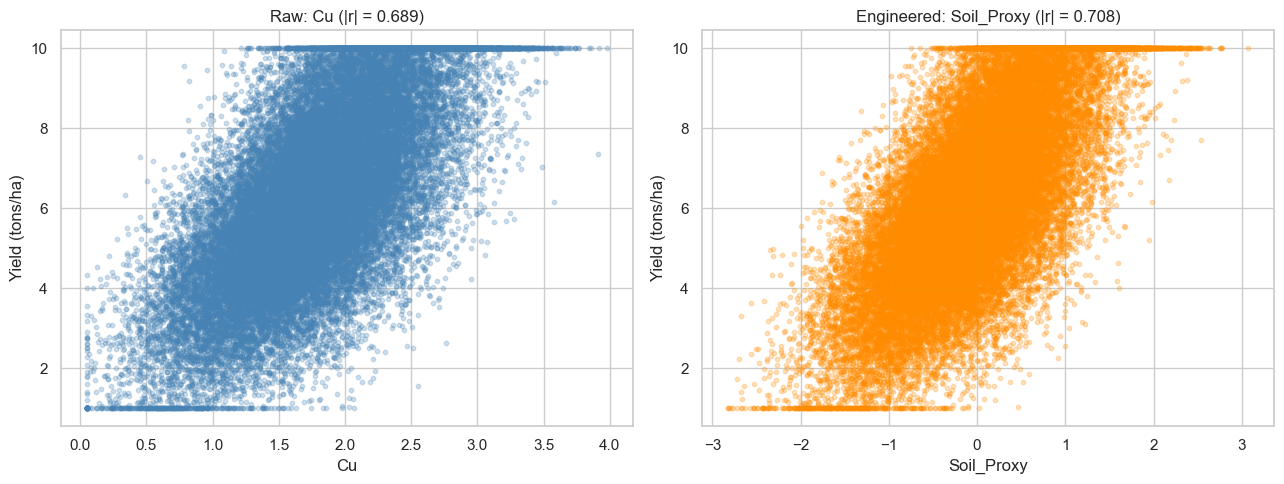

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(df_raw[raw_top], df_raw['Yield'], color='steelblue', alpha=0.25, s=10)
axes[0].set_xlabel(raw_top)
axes[0].set_ylabel('Yield (tons/ha)')
axes[0].set_title(f'Raw: {raw_top} (|r| = {raw_max:.3f})')
axes[1].scatter(df[eng_top], df['Yield'], color='darkorange', alpha=0.25, s=10)
axes[1].set_xlabel(eng_top)
axes[1].set_ylabel('Yield (tons/ha)')
axes[1].set_title(f'Engineered: {eng_top} (|r| = {eng_max:.3f})')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fe_raw_vs_engineered_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Train / test split

In [8]:
cat_cols = ['Crop_Type', 'Soil_Type', 'Fertilizer_Type', 'Pesticide_Usage', 'Growth_Stage', 'Region', 'Season']
feature_cols = [c for c in df.columns if c not in {'Yield', 'Year'}]
num_cols = [c for c in feature_cols if c not in cat_cols]

X = df[feature_cols].copy()
y = df['Yield'].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Numeric features: {len(num_cols)}, Categorical features: {len(cat_cols)}')

X_train.to_csv(PROC_DIR / 'X_train_filtered.csv', index=False)
X_test.to_csv(PROC_DIR / 'X_test_filtered.csv', index=False)
y_train.to_csv(PROC_DIR / 'y_train.csv', index=False)
y_test.to_csv(PROC_DIR / 'y_test.csv', index=False)

Train: (28800, 61), Test: (7200, 61)
Numeric features: 54, Categorical features: 7


## Preprocessor and feature metadata

We use:

- median imputation on numeric columns (robust to outliers, even though we have no missing values today this keeps the pipeline safe for future data)
- StandardScaler on numerics (linear models and KNN need it)
- one-hot encoding on the seven categorical columns

The fitted preprocessor is saved so notebooks 03 and 04 use the same transformation as the dashboard.

In [9]:
num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer([('num', num_pipe, num_cols), ('cat', cat_pipe, cat_cols)])

joblib.dump(preprocessor, MODEL_DIR / 'preprocessor.joblib')
joblib.dump({'feature_cols': feature_cols, 'num_cols': num_cols, 'cat_cols': cat_cols},
            MODEL_DIR / 'feature_meta.joblib')
print('Saved preprocessor.joblib and feature_meta.joblib')

Saved preprocessor.joblib and feature_meta.joblib
